# 集成学习

在机器学习领域，集成学习（Ensemble Learning）是一种通过结合多个模型的预测结果来提高整体性能的技术。

集成学习的核心思想是"三个臭皮匠，顶个诸葛亮"，即通过多个弱学习器的组合，可以构建一个强学习器。

集成学习的主要目标是通过组合多个模型来提高预测的准确性和鲁棒性。

常见的集成学习方法包括：

- 1. Bagging（Bootstrap Aggregating）：通过自助采样法（Bootstrap Sampling）生成多个训练集，然后分别训练多个模型，最后通过投票或平均的方式得到最终结果。
- 2. Boosting（提升方法）：通过逐步调整样本权重，训练一系列弱学习器，每个学习器都试图纠正前一个学习器的错误，最终将这些弱学习器组合成一个强学习器。
- 3. Stacking（堆叠）：通过训练多个不同的模型，然后将这些模型的输出作为新的特征，再训练一个元模型（Meta-Model）来进行最终的预测。

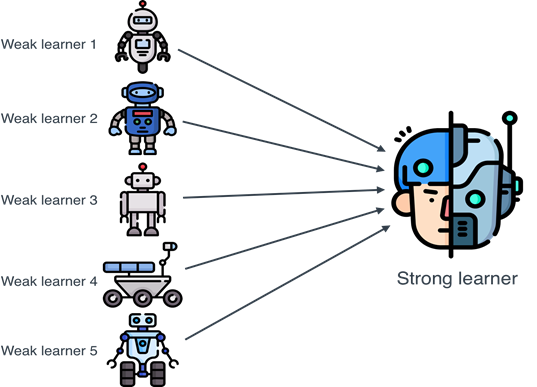

### 1. Bagging（Bootstrap Aggregating）
Bagging是一种通过自助采样法生成多个训练集的方法。每个训练集都是从原始数据集中随机抽取的，允许重复抽取。然后，分别训练多个模型，并通过投票或平均的方式得到最终结果。它通过以下步骤实现：
- 数据集重采样：对训练数据集进行多次有放回的随机采样（bootstrap），每次采样得到一个子数据集。
- 训练多个模型：在每个子数据集上训练一个基学习器（通常是相同类型的模型）。
- 结果合并：将多个基学习器的结果进行合并，通常是通过投票（分类问题）或平均（回归问题）。

#### 典型的Bagging算法:
- 随机森林（Random Forest），它通过构建多个决策树来实现集成学习 , 从而减少过拟合并提高模型的泛化能力。

#### 优势:
- 可以有效减少方差，提高模型稳定性。
- 适用于高方差的模型，如决策树。

#### 劣势:
- 训练过程时间较长，因为需要训练多个模型。
- 结果难以解释，因为没有单一的模型。

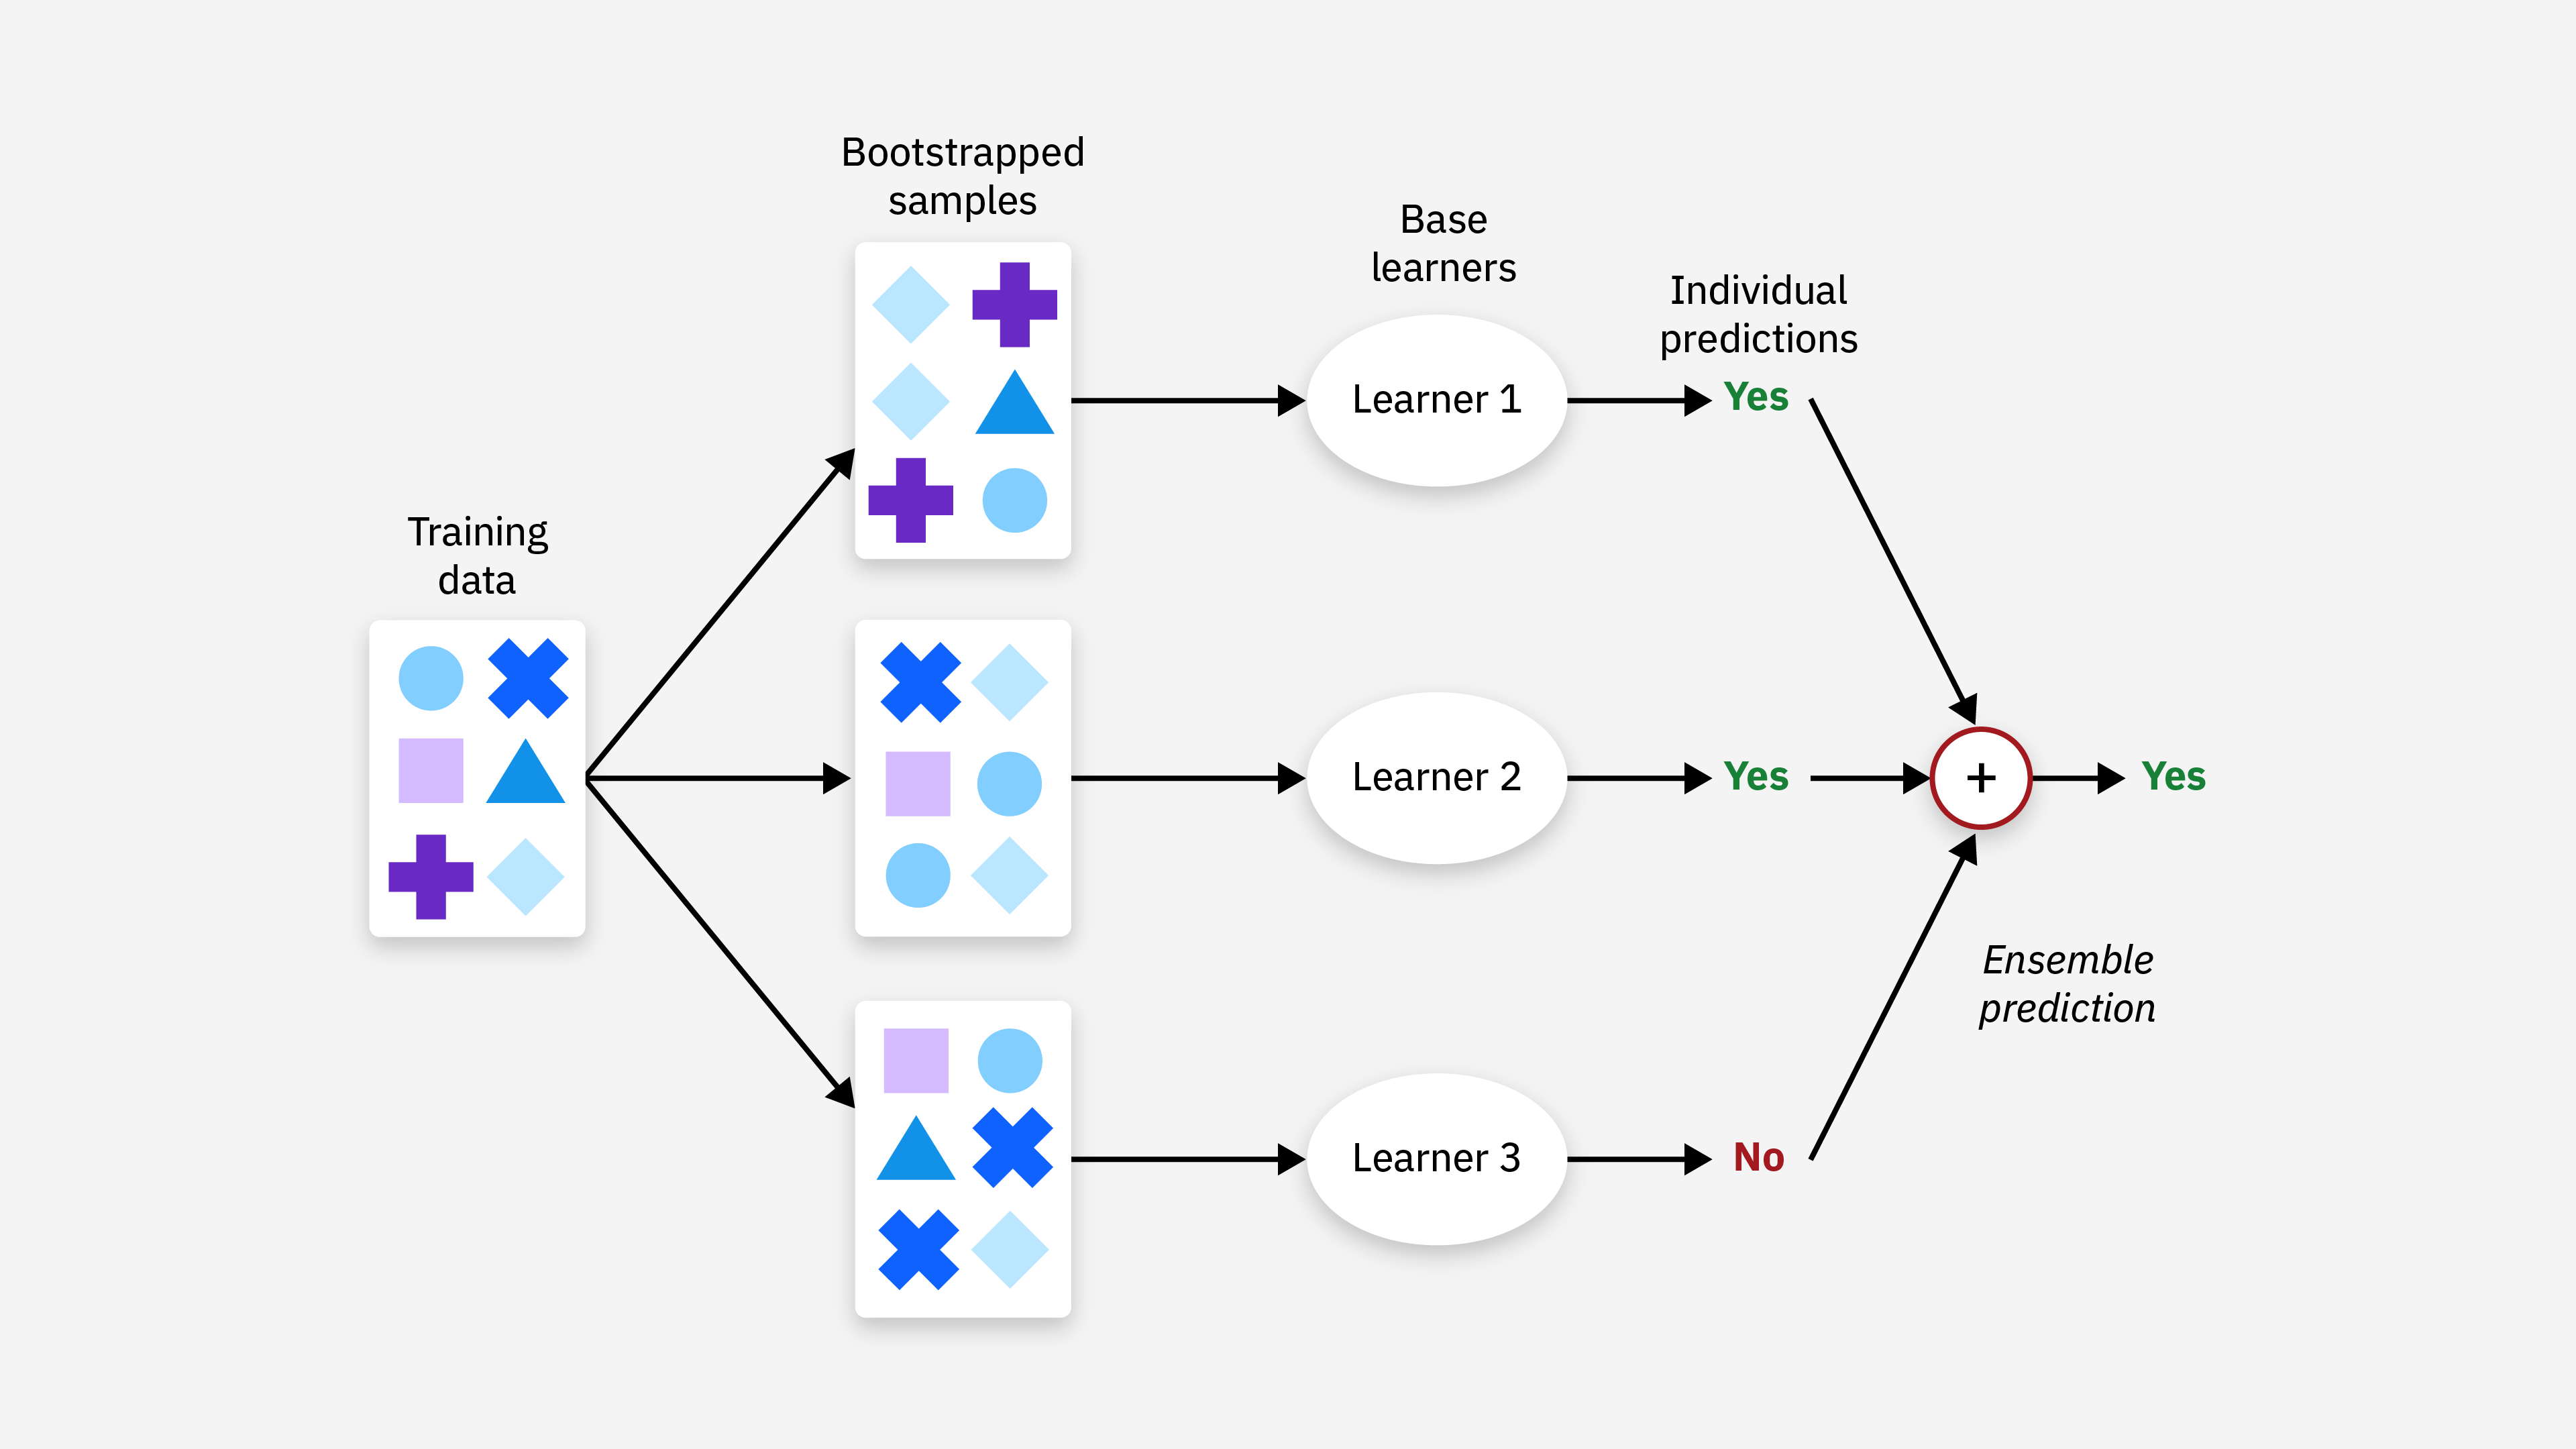

-----

### 2. Boosting（提升方法）
Boosting 的目标是通过减少模型的偏差来提高性能，适用于弱学习器。Boosting 的核心思想是逐步调整每个模型的权重，强调那些被前一轮模型错误分类的样本。Boosting 通过以下步骤实现：
- 序列化训练：模型是一个接一个地训练的，每一轮训练都会根据前一轮的错误进行调整。
- 加权投票：最终的预测是所有弱学习器预测的加权和，其中错误分类的样本会被赋予更高的权重。
- 合并模型：每个模型的权重是根据其在训练过程中的表现来确定的。

#### 典型的Boosting算法:
- AdaBoost（Adaptive Boosting），它通过调整样本权重来训练一系列弱学习器。
- 梯度提升树（Gradient Boosting Trees, GBT）：GBT 通过迭代优化目标函数，逐步减少偏差。
- XGBoost（Extreme Gradient Boosting）：XGBoost 是一种高效的梯度提升算法，广泛应用于数据科学竞赛中，具有较强的性能和优化。
- LightGBM（Light Gradient Boosting Machine）：LightGBM 是一种基于梯度提升树的框架，相较于 XGBoost，具有更快的训练速度和更低的内存使用。


#### 优势:
- 适用于偏差较大的模型，能有效提高预测准确性。
- 强大的性能，在许多实际应用中表现优异。

#### 劣势:
- 对噪声数据敏感，可能导致过拟合。
- 训练时间较长，尤其是在数据量较大时。

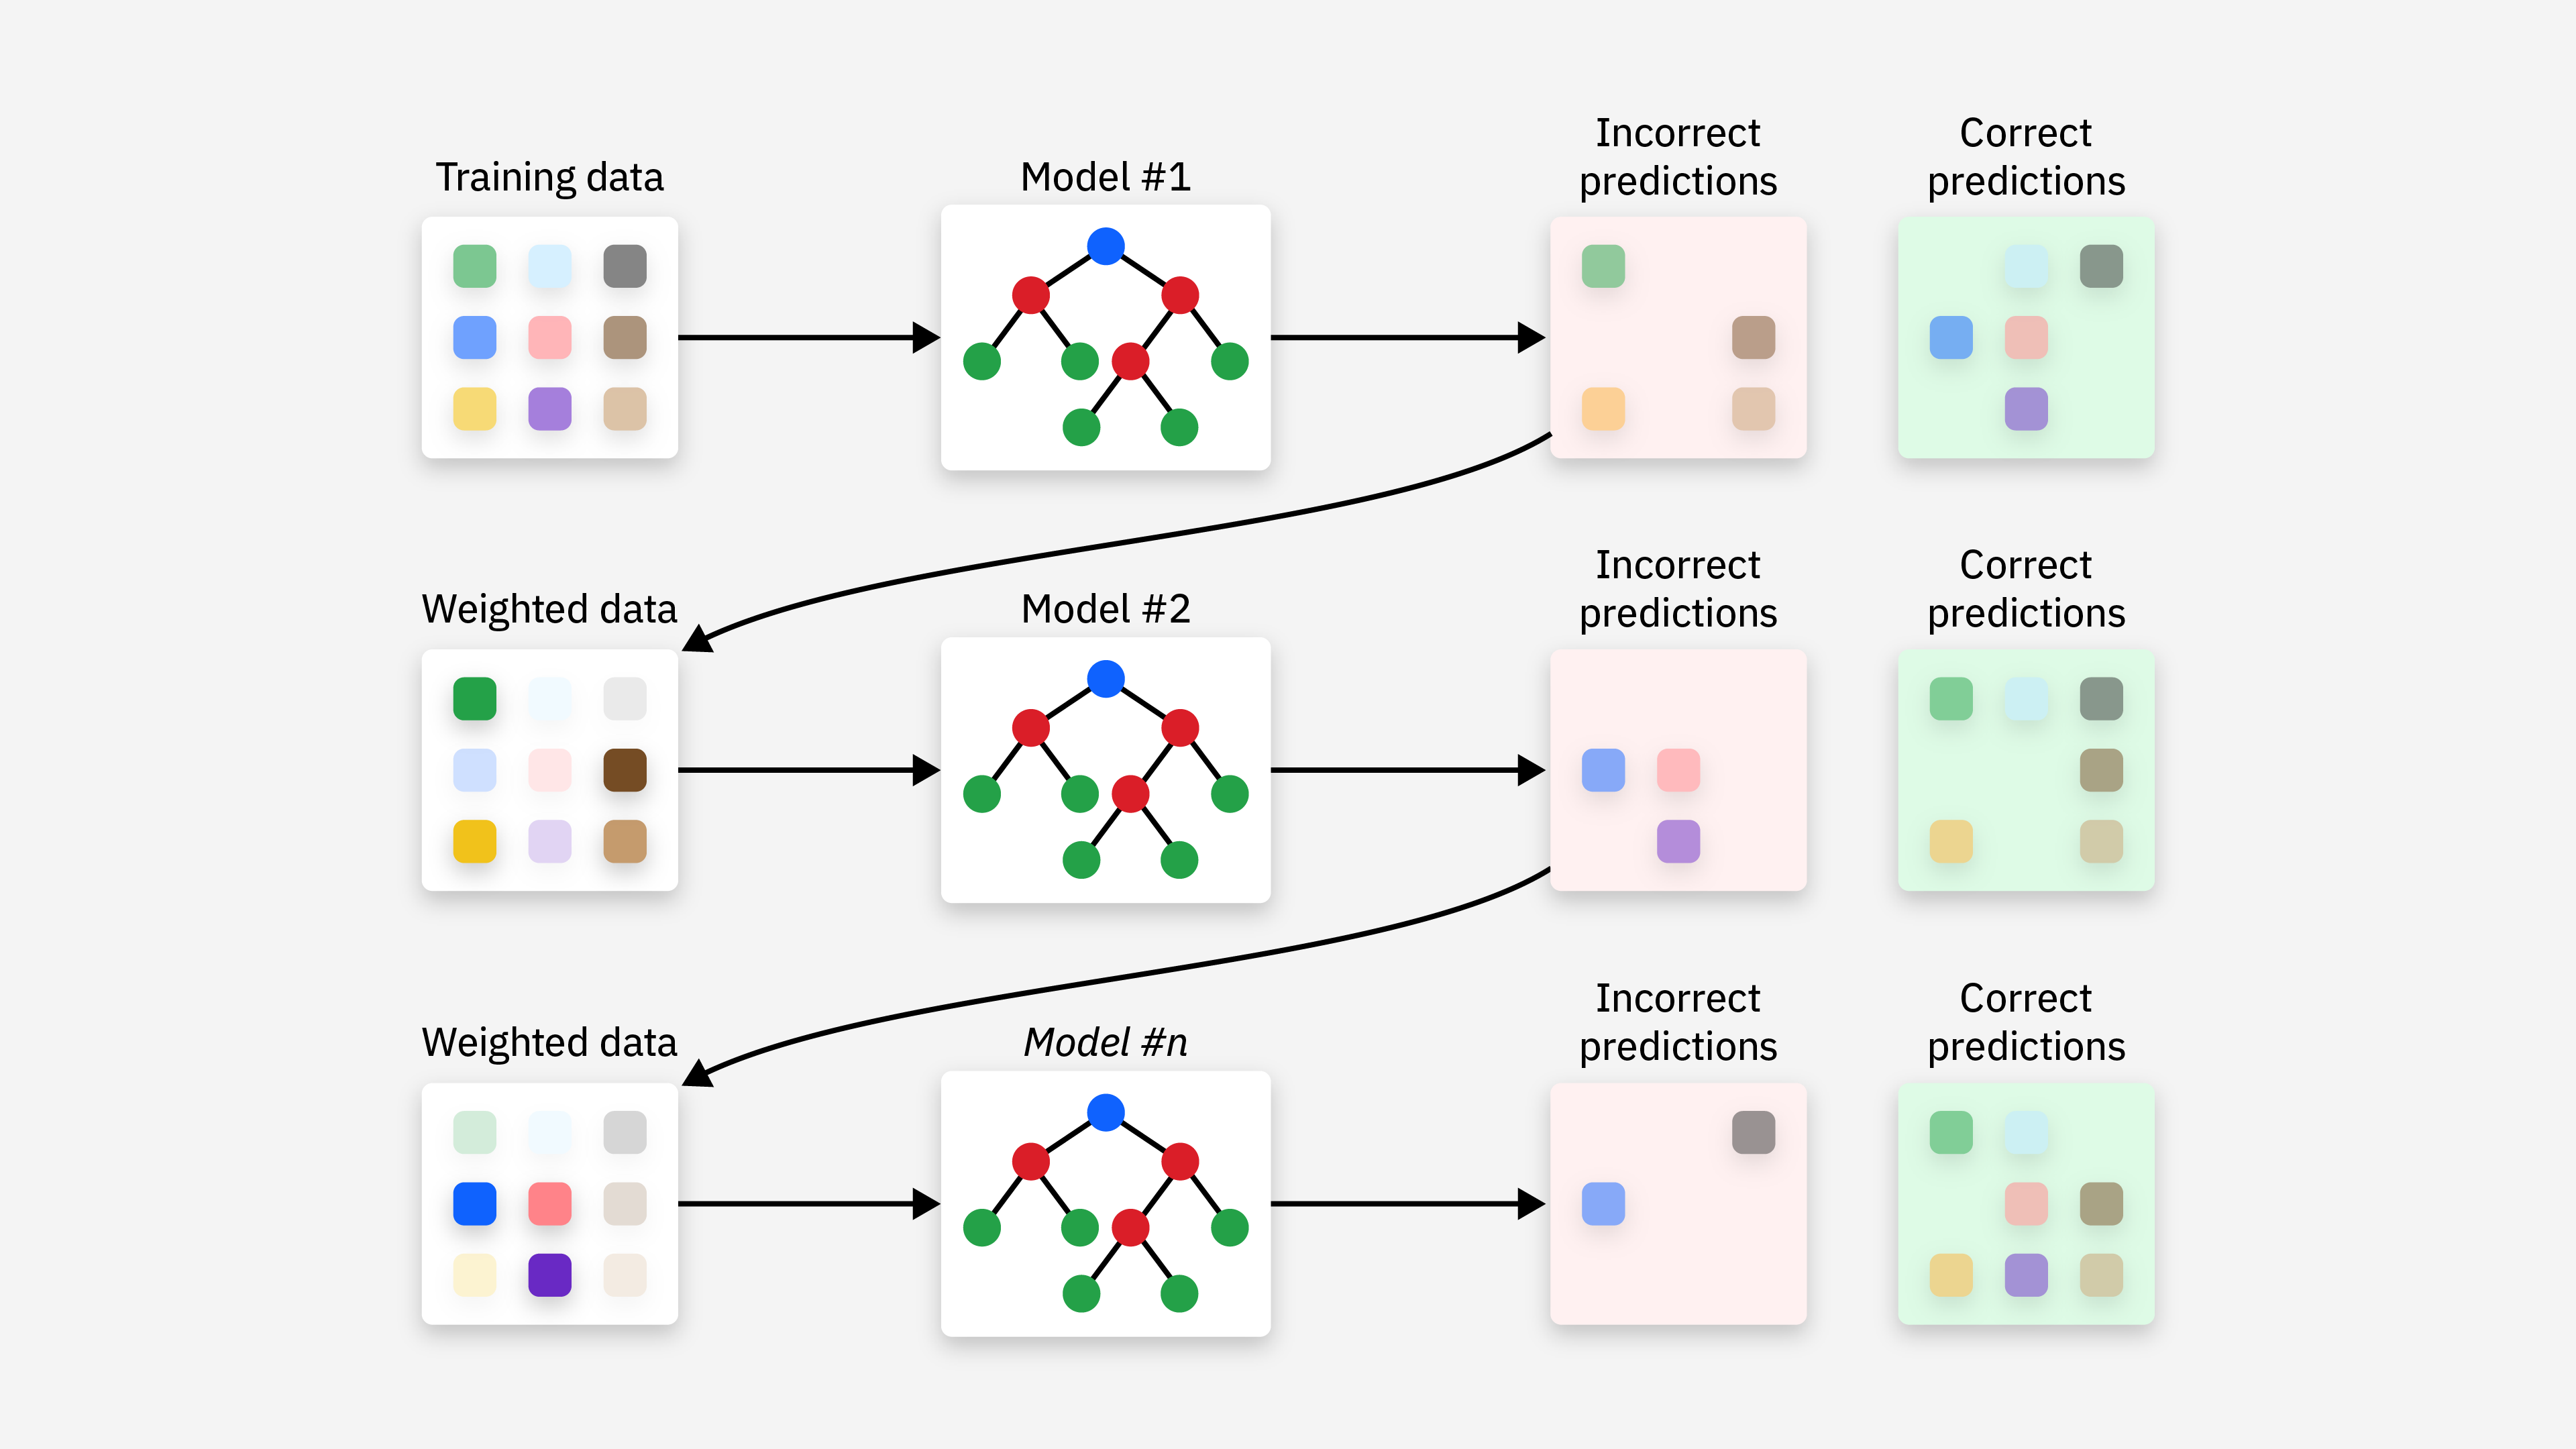

------

### 3. Stacking（Stacked Generalization）
Stacking 是一种通过训练多个不同类型的模型来提高预测性能的方法。它通过以下步骤实现：
- 第一层（基学习器）：训练多个不同类型的基学习器（例如，决策树、SVM、KNN 等）来对数据进行预测。
- 第二层（元学习器）：将第一层学习器的预测结果作为输入，训练一个元学习器（通常是逻辑回归、线性回归等），来做最终的预测。

#### 优势:
- 可以使用不同类型的基学习器，捕捉数据中不同的模式。
- 理论上可以结合多种模型的优势，达到更强的预测能力。

#### 劣势:
- 训练过程复杂，需要对多个模型进行训练，且模型之间的结合方式也需要精心设计。
- 比其他集成方法如 Bagging 和 Boosting 更复杂，且容易过拟合。

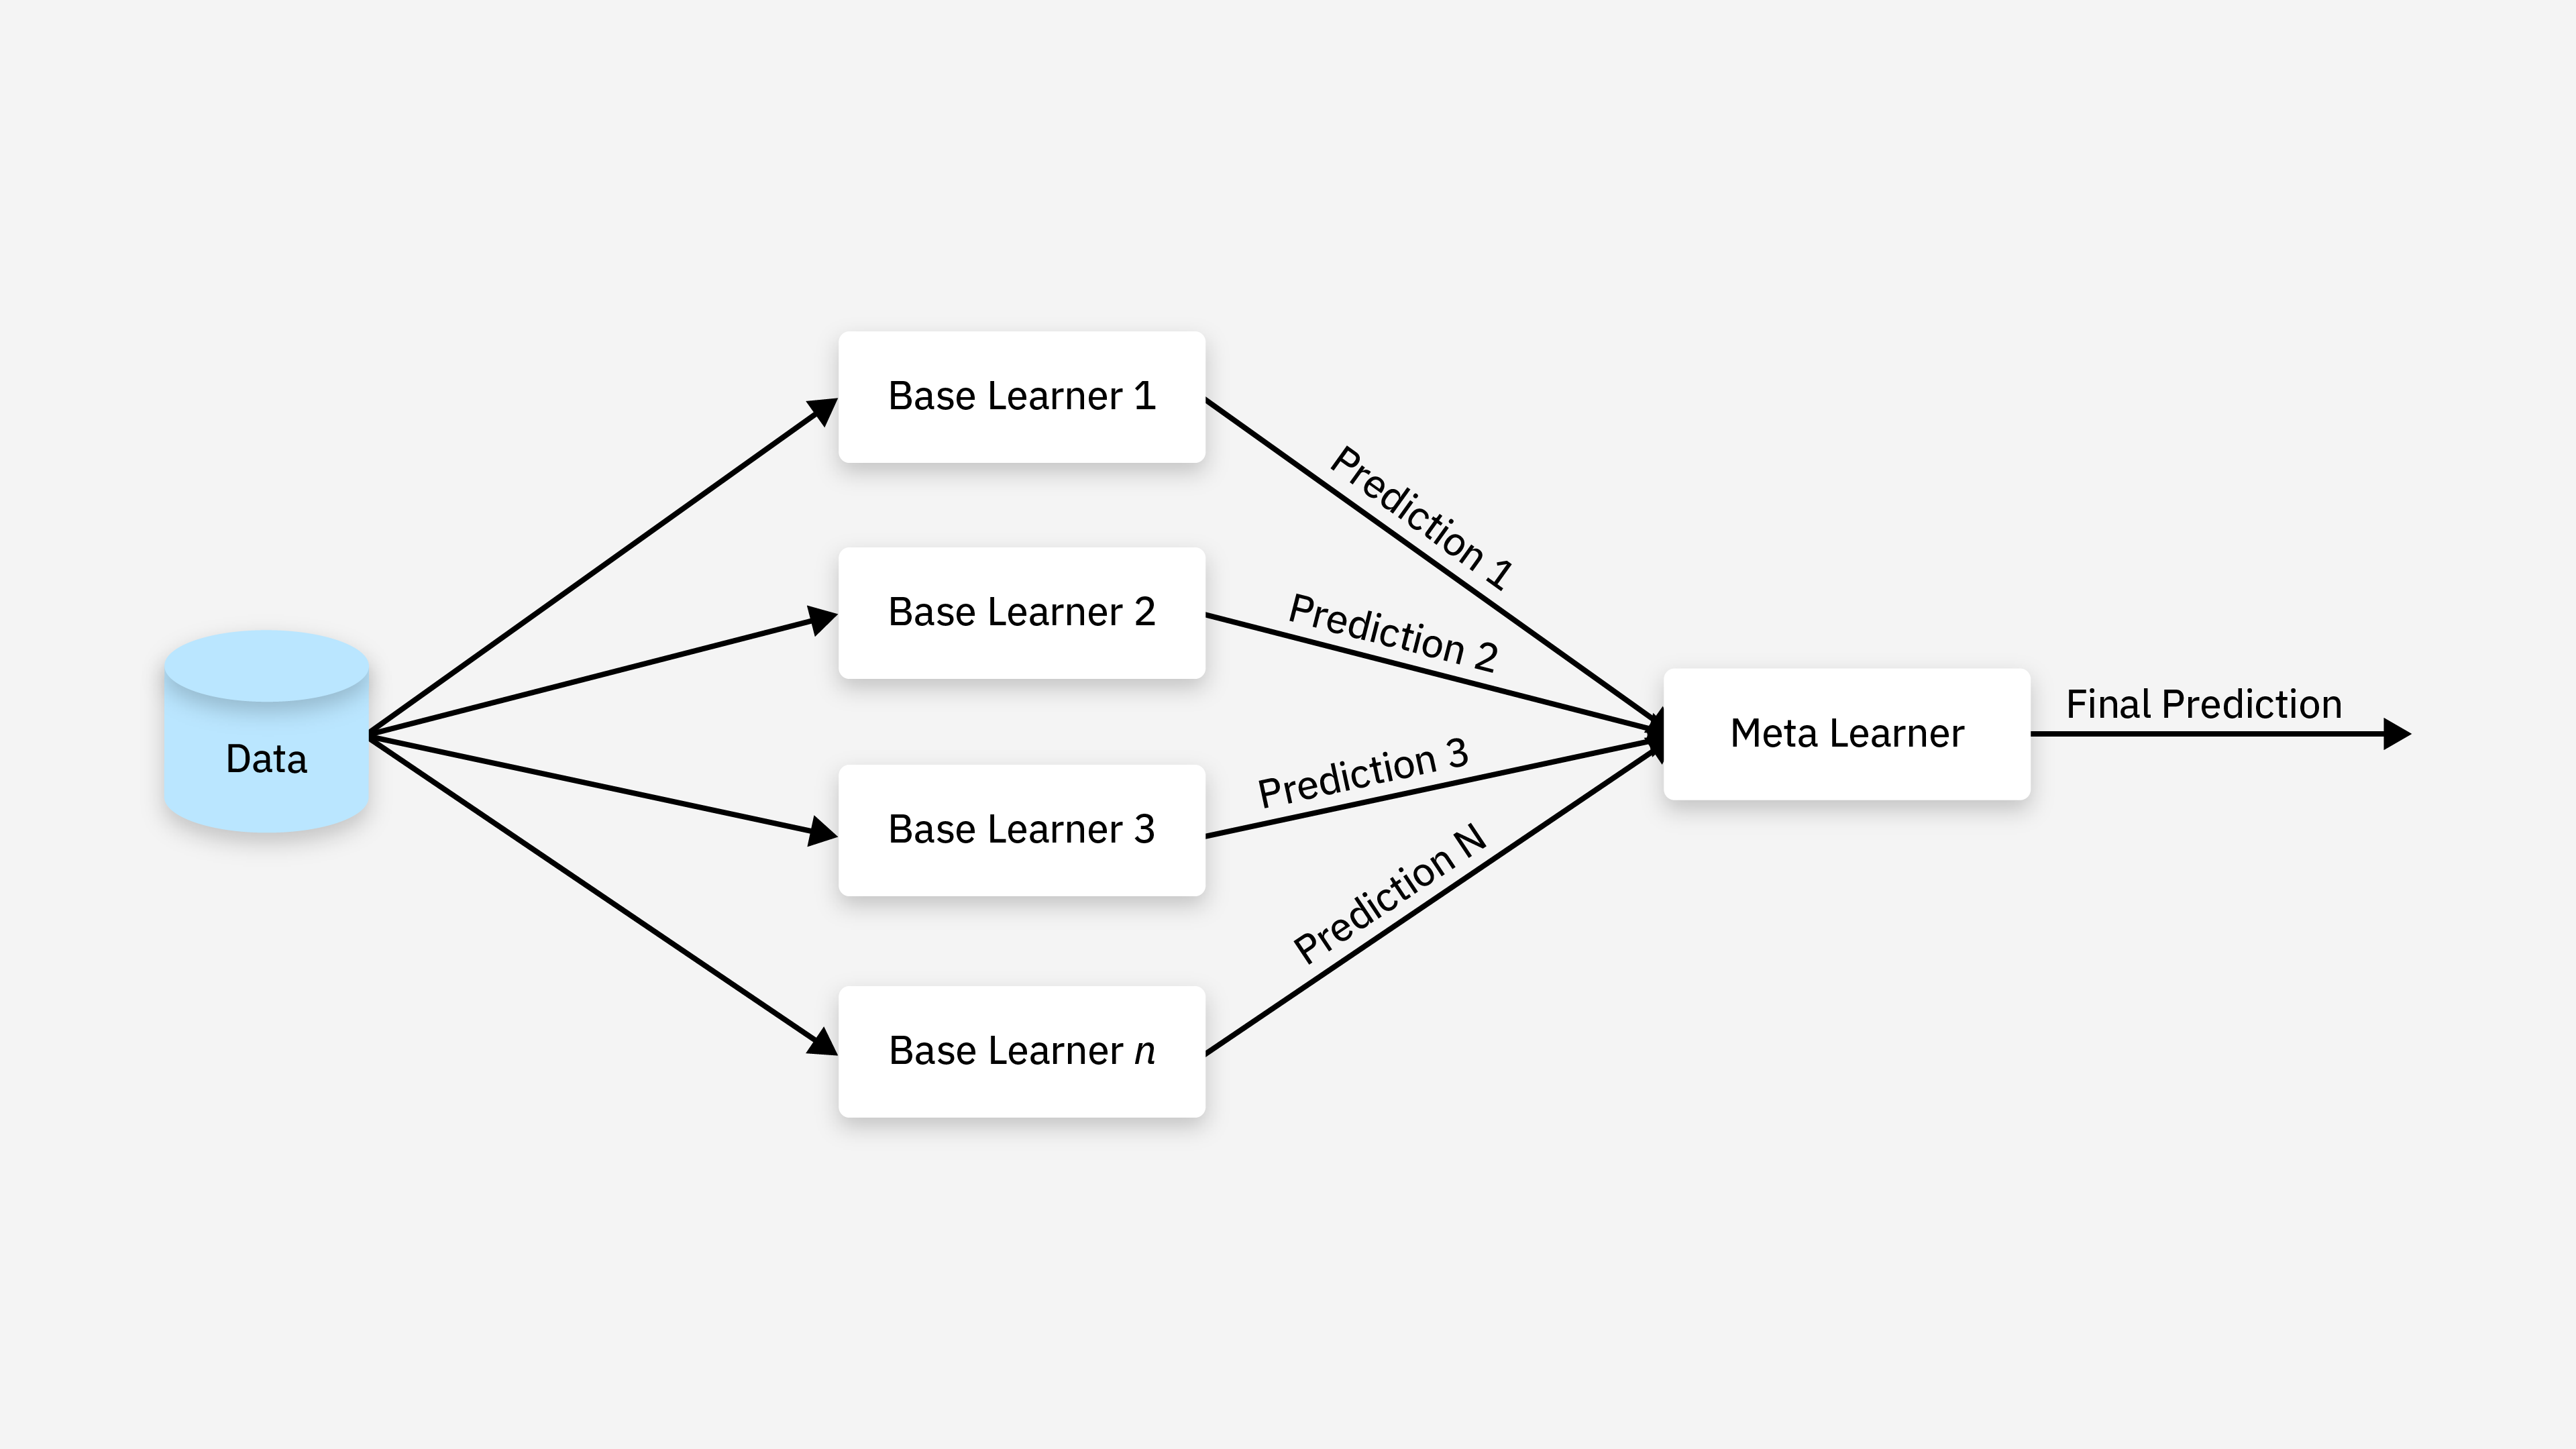


---------

### 实例演示

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 加载数据集
iris = load_iris()
X, y = iris.data, iris.target

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 创建随机森林分类器
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 训练模型
rf.fit(X_train, y_train)

# 预测
y_pred = rf.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"随机森林的准确率: {accuracy:.2f}")

随机森林的准确率: 1.00


#### Boosting算法示例：使用AdaBoost进行分类
算法原理: Boosting 的核心思想是通过迭代的方式训练多个模型，每个模型都试图纠正前一个模型的错误。AdaBoost（Adaptive Boosting）是Boosting算法中最经典的一种。

In [2]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

# 加载数据集
iris = load_iris()
X, y = iris.data, iris.target

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 使用默认的弱学习器（决策树），并指定使用 SAMME 算法
aada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1), # 建议改名为 estimator , max_depth=1 是决策树的最大深度，限制弱学习器的复杂度
    n_estimators=50,
    random_state=42
)                   # n_estimators 是迭代次数，弱学习器的数量

# 训练模型
aada.fit(X_train, y_train)

# 预测
y_pred = aada.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"AdaBoost的准确率: {accuracy:.2f}")

AdaBoost的准确率: 1.00


#### Stacking : 堆叠
算法原理: Stacking 是一种通过训练多个不同类型的模型来提高预测性能的方法。它通过将第一层学习器的预测结果作为输入，训练一个元学习器来做最终的预测。

In [3]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 加载数据集
iris = load_iris()
X, y = iris.data, iris.target

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 定义基学习器
estimators = [
    ('dt', DecisionTreeClassifier(max_depth=1)),
    ('svc', SVC(kernel='linear', probability=True))
]

# 创建Stacking分类器
stacking = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())

# 训练模型
stacking.fit(X_train, y_train)

# 预测
y_pred = stacking.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"Stacking的准确率: {accuracy:.2f}")

Stacking的准确率: 1.00
